# House Price Prediction

1. Import libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, accuracy_score, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

2. load the dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving house_price.csv to house_price.csv


In [2]:
data = pd.read_csv("house_price.csv")

In [3]:
data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [5]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [14]:
data.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [39]:
data.duplicated().sum()


np.int64(0)

In [ ]:
data.drop('pricr', axis=1, inplace=True)

In [6]:
data.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [16]:
data["price"].describe()

,price
count,4.600000e+03
mean,5.519630e+05
std,5.638347e+05
min,0.000000e+00
25%,3.228750e+05
50%,4.609435e+05
75%,6.549625e+05
max,2.659000e+07


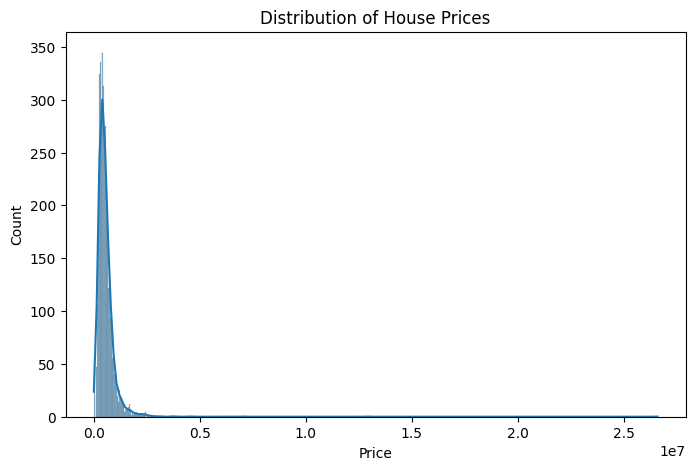

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(data["price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.show()


In [9]:
# Split data into X and y

In [21]:
features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated"
]

X = data[features]
y = data['price']

In [23]:
# Split the dat into training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42 )

In [20]:
print(X_train.dtypes)

date              object
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street            object
city              object
statezip          object
country           object
dtype: object


In [24]:
X_train.shape, X_test.shape

((3680, 12), (920, 12))

In [25]:
y_train.shape, y_test.shape

((3680,), (920,))

In [26]:
#train the model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [28]:
y_pred = model.predict(X_test)
y_pred

array([ 304863.38578076,  326517.06991516, 1071762.53630098,
        546241.40097359,  379799.98321087,  605792.9362275 ,
        481263.57120657,  418905.11058143,  509341.50791926,
        530852.97588255,  682958.97641218,  414525.36130069,
        836974.40259905,  416500.85730826,  367263.4338823 ,
        702908.51672181,  677878.69067807,  515539.32998557,
       1019380.63891391,  861119.79490667, 1364866.21814685,
        637439.70016771,  634739.5666634 ,  470424.21250268,
        162037.1538305 ,  232831.37648252,  669951.05071604,
        884080.66694998,  263027.2257721 ,  974954.64229479,
       1883342.16391312,  481510.29664868, 1275554.65253673,
        430994.93178867,  180366.40705427,  339240.17357425,
        792335.74094019, 1011053.14613377,  238036.20927684,
        543438.66040786,  423414.50597295,  243429.92107977,
        390151.30073943,  361322.67375659,  320343.34636021,
        317865.29287651,  469559.60646627,  573249.20158981,
        828966.75691607,

## Calculate the metrics

In [35]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 210908.17325009225
MSE: 986921767056.0986
RMSE: 993439.3625461488
R²: 0.032283856632802865


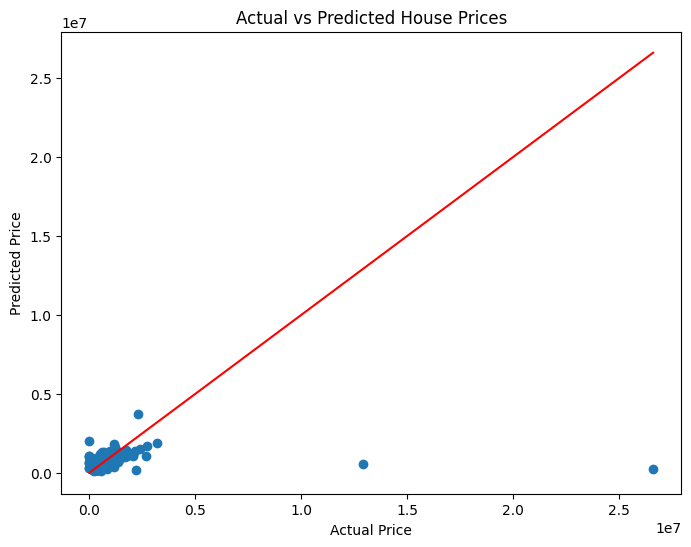

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()


In [49]:
new_house = [[
    3,       # bedrooms
    3,       # bathrooms
    1800,    # sqft_living
    5000,    # sqft_lot
    1,       # floors
    0,       # waterfront
    0,       # view
    3,       # condition
    1800,    # sqft_above
    0,       # sqft_basement
    2000,    # yr_built
    0        # yr_renovated
]]

prediction = model.predict(new_house)

print("Predicted House Price: ${:,.2f}".format(prediction[0]))


Predicted House Price: $367,878.42


In conclusion, we successfully developed a Linear Regression model for house-price prediction. The model was trained using property-related features and was able to predict the price of a new house at $367,878.42.